In [19]:
import pickle
import numpy as np


In [20]:
with open('/projects/kernlab/akapoor/pg_gpu/traditional/MomentsLD_results/means.varcovs.traditional.100_reps.bp', 'rb') as f:
    traditional_data = pickle.load(f)

In [21]:
traditional_data

{'bins': [(0.0, 1e-06),
  (1e-06, 1.584893192461114e-06),
  (1.584893192461114e-06, 2.5118864315095823e-06),
  (2.5118864315095823e-06, 3.981071705534969e-06),
  (3.981071705534969e-06, 6.30957344480193e-06),
  (6.30957344480193e-06, 9.999999999999999e-06),
  (9.999999999999999e-06, 1.584893192461114e-05),
  (1.584893192461114e-05, 2.5118864315095822e-05),
  (2.5118864315095822e-05, 3.9810717055349695e-05),
  (3.9810717055349695e-05, 6.309573444801929e-05),
  (6.309573444801929e-05, 9.999999999999999e-05),
  (9.999999999999999e-05, 0.00015848931924611142),
  (0.00015848931924611142, 0.0002511886431509582),
  (0.0002511886431509582, 0.0003981071705534973),
  (0.0003981071705534973, 0.0006309573444801936),
  (0.0006309573444801936, 0.001)],
 'stats': (['DD_0_0',
   'DD_0_1',
   'DD_1_1',
   'Dz_0_0_0',
   'Dz_0_0_1',
   'Dz_0_1_1',
   'Dz_1_0_0',
   'Dz_1_0_1',
   'Dz_1_1_1',
   'pi2_0_0_0_0',
   'pi2_0_0_0_1',
   'pi2_0_0_1_1',
   'pi2_0_1_0_1',
   'pi2_0_1_1_1',
   'pi2_1_1_1_1'],
  ['

In [22]:
traditional_data['means'][15]

array([0.1120233 , 0.00987387, 0.02577069, 0.06305245, 0.00310254,
       0.00285556, 0.0353474 , 0.00213696, 0.00346814, 1.        ,
       1.31161966, 1.29658663, 1.74757771, 1.72837899, 1.72588682])

In [23]:
with open('/projects/kernlab/akapoor/pg_gpu/GPU/MomentsLD_results/means.varcovs.gpu.100_reps.bp', 'rb') as f:
    gpu_data = pickle.load(f)

In [24]:
gpu_data['means'][15]

array([0.11163848, 0.00968078, 0.02628967, 0.06172917, 0.00272747,
       0.00308877, 0.03599448, 0.00323094, 0.00425654, 1.        ,
       1.32070606, 1.30602537, 1.7603573 , 1.7415001 , 1.72246577])

In [25]:
import numpy as np
import pickle

# Load data
with open('/projects/kernlab/akapoor/pg_gpu/traditional/MomentsLD_results/means.varcovs.traditional.100_reps.bp', 'rb') as f:
    traditional_data = pickle.load(f)
with open('/projects/kernlab/akapoor/pg_gpu/GPU/MomentsLD_results/means.varcovs.gpu.100_reps.bp', 'rb') as f:
    gpu_data = pickle.load(f)

# Select array 15 (index 15 because Python is 0-indexed)
i = 15
trad_array = np.array(traditional_data['means'][i])
gpu_array = np.array(gpu_data['means'][i])

# Compute differences
diff = np.abs(trad_array - gpu_array)
max_idx = np.argmax(diff)

print(f"\n=== Array {i} Comparison ===")
print(f"Moments array shape: {trad_array.shape}")
print(f"GPU array shape:         {gpu_array.shape}")
print(f"Mean abs diff: {diff.mean():.6f}")
print(f"Max abs diff:  {diff.max():.6f} (at index {max_idx})")

# Print the specific values that caused the largest difference
print("\n--- Element with Max Difference ---")
print(f"Moments[{max_idx}] = {trad_array[max_idx]}")
print(f"GPU[{max_idx}]          = {gpu_array[max_idx]}")
print(f"Absolute difference     = {diff[max_idx]}")

# (Optional) Print summary statistics for context
print("\n--- Summary ---")
print(f"Min Moments value: {trad_array.min():.6e}")
print(f"Max Moments value: {trad_array.max():.6e}")
print(f"Min gpu value:  {gpu_array.min():.6e}")
print(f"Max gpu value:  {gpu_array.max():.6e}")



=== Array 15 Comparison ===
Moments array shape: (15,)
GPU array shape:         (15,)
Mean abs diff: 0.003560
Max abs diff:  0.013121 (at index 13)

--- Element with Max Difference ---
Moments[13] = 1.7283789938528613
GPU[13]          = 1.7415000992671317
Absolute difference     = 0.013121105414270362

--- Summary ---
Min Moments value: 2.136955e-03
Max Moments value: 1.747578e+00
Min gpu value:  2.727475e-03
Max gpu value:  1.760357e+00


In [26]:
# Calculate element-wise differences between traditional and GPU data
import numpy as np

# Ensure both lists have the same length
assert len(traditional_data['means']) == len(gpu_data['means']), "Lists must have same length"

# Calculate element-wise differences for each array
differences = []
for i in range(len(traditional_data['means'])):
    trad_array = traditional_data['means'][i]
    gpu_array = gpu_data['means'][i]
    
    # Calculate absolute difference
    diff = np.abs(trad_array - gpu_array)
    differences.append(diff)
    
    print(f"Array {i:2d}: Mean abs diff = {diff.mean():.6f}, Max abs diff = {diff.max():.6f}")

# Calculate overall statistics
all_differences = np.concatenate(differences)
print(f"\nOverall Statistics:")
print(f"Mean absolute difference: {all_differences.mean():.6f}")
print(f"Std absolute difference:  {all_differences.std():.6f}")
print(f"Max absolute difference:  {all_differences.max():.6f}")
print(f"Min absolute difference:  {all_differences.min():.6f}")

# Calculate relative differences (as percentages)
print(f"\nRelative Differences (as percentages):")
relative_diffs = []
for i in range(len(traditional_data['means'])):
    trad_array = traditional_data['means'][i]
    gpu_array = gpu_data['means'][i]
    
    # Calculate relative difference (avoid division by zero)
    rel_diff = np.abs(trad_array - gpu_array) / (np.abs(trad_array) + 1e-10) * 100
    relative_diffs.append(rel_diff)
    
    print(f"Array {i:2d}: Mean rel diff = {rel_diff.mean():.4f}%, Max rel diff = {rel_diff.max():.4f}%")

all_relative_diffs = np.concatenate(relative_diffs)
print(f"\nOverall Relative Statistics:")
print(f"Mean relative difference: {all_relative_diffs.mean():.4f}%")
print(f"Max relative difference:  {all_relative_diffs.max():.4f}%")

Array  0: Mean abs diff = 0.001177, Max abs diff = 0.006160
Array  1: Mean abs diff = 0.002911, Max abs diff = 0.009496
Array  2: Mean abs diff = 0.001841, Max abs diff = 0.007859
Array  3: Mean abs diff = 0.001378, Max abs diff = 0.006033
Array  4: Mean abs diff = 0.001659, Max abs diff = 0.005981
Array  5: Mean abs diff = 0.001284, Max abs diff = 0.003413
Array  6: Mean abs diff = 0.001294, Max abs diff = 0.004480
Array  7: Mean abs diff = 0.001368, Max abs diff = 0.003135
Array  8: Mean abs diff = 0.001138, Max abs diff = 0.002758
Array  9: Mean abs diff = 0.001199, Max abs diff = 0.002111
Array 10: Mean abs diff = 0.001914, Max abs diff = 0.003294
Array 11: Mean abs diff = 0.001979, Max abs diff = 0.005066
Array 12: Mean abs diff = 0.002179, Max abs diff = 0.006406
Array 13: Mean abs diff = 0.002662, Max abs diff = 0.008433
Array 14: Mean abs diff = 0.002926, Max abs diff = 0.010333
Array 15: Mean abs diff = 0.003560, Max abs diff = 0.013121
Array 16: Mean abs diff = 0.023394, Max 

In [27]:
np.allclose(gpu_array, trad_array, rtol=1e-2, atol=1e-3)

False

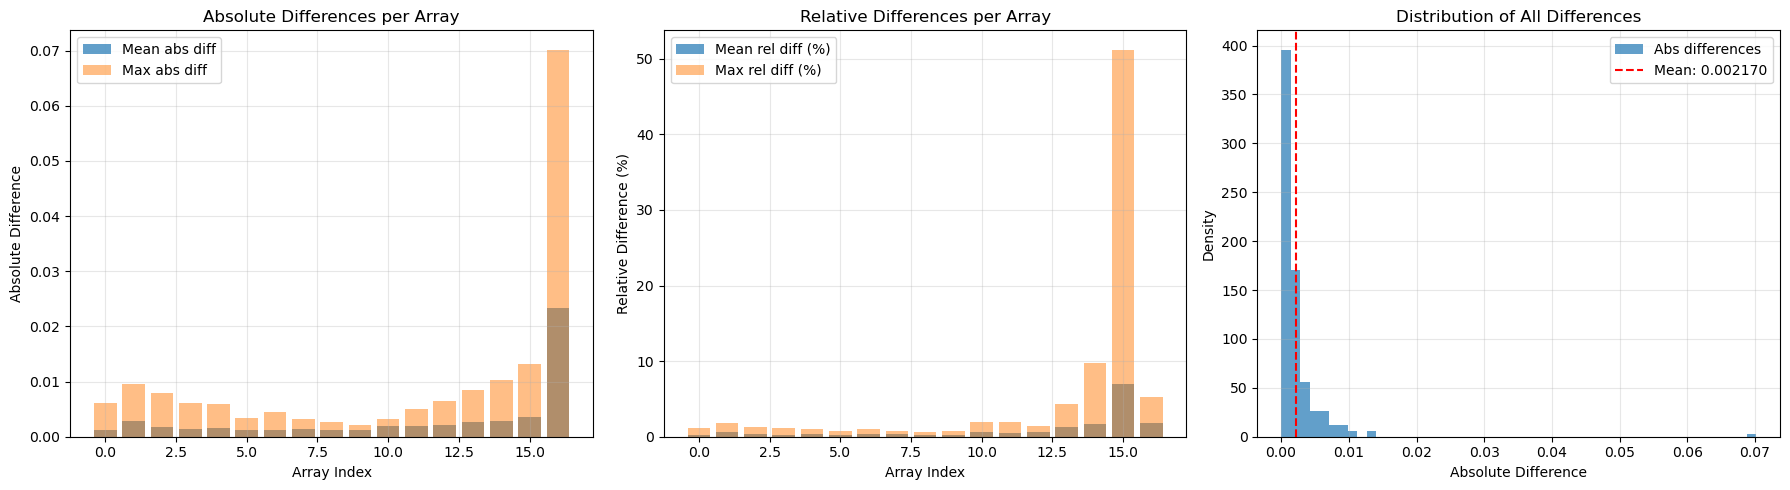


SUMMARY: GPU vs Traditional Comparison
Total arrays compared: 17
Total elements compared: 243
Agreement level: 99.06%


In [28]:
# Visualize the differences
import matplotlib.pyplot as plt

# Create a comparison plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mean absolute differences per array
array_indices = range(len(differences))
mean_diffs = [diff.mean() for diff in differences]
max_diffs = [diff.max() for diff in differences]

ax1.bar(array_indices, mean_diffs, alpha=0.7, label='Mean abs diff')
ax1.bar(array_indices, max_diffs, alpha=0.5, label='Max abs diff')
ax1.set_xlabel('Array Index')
ax1.set_ylabel('Absolute Difference')
ax1.set_title('Absolute Differences per Array')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Relative differences per array
mean_rel_diffs = [rel_diff.mean() for rel_diff in relative_diffs]
max_rel_diffs = [rel_diff.max() for rel_diff in relative_diffs]

ax2.bar(array_indices, mean_rel_diffs, alpha=0.7, label='Mean rel diff (%)')
ax2.bar(array_indices, max_rel_diffs, alpha=0.5, label='Max rel diff (%)')
ax2.set_xlabel('Array Index')
ax2.set_ylabel('Relative Difference (%)')
ax2.set_title('Relative Differences per Array')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of all differences
ax3.hist(all_differences, bins=50, alpha=0.7, density=True, label='Abs differences')
ax3.axvline(all_differences.mean(), color='red', linestyle='--', 
           label=f'Mean: {all_differences.mean():.6f}')
ax3.set_xlabel('Absolute Difference')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of All Differences')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics in a nice format
print(f"\n{'='*60}")
print(f"SUMMARY: GPU vs Traditional Comparison")
print(f"{'='*60}")
print(f"Total arrays compared: {len(traditional_data['means'])}")
print(f"Total elements compared: {len(all_differences)}")
print(f"Agreement level: {100 - all_relative_diffs.mean():.2f}%")
print(f"{'='*60}")

R² = 0.999915


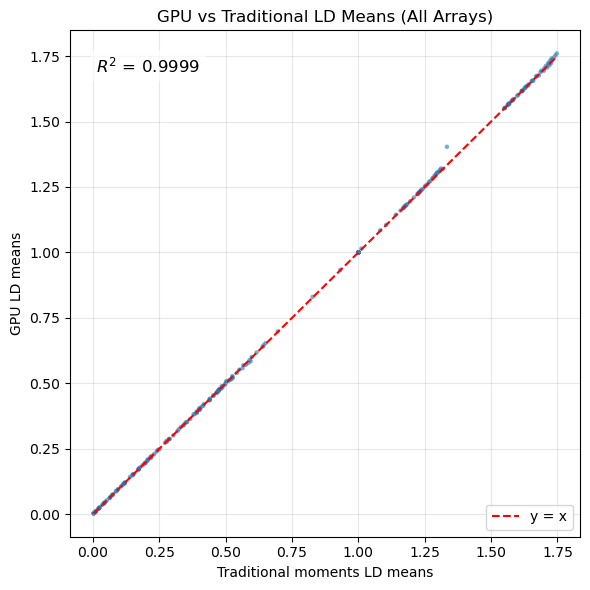

In [29]:
# Plot 4: Scatterplot of GPU vs Traditional (per array)
fig, ax = plt.subplots(figsize=(6, 6))

# Flatten all values into one vector for direct comparison
trad_flat = np.concatenate(traditional_data['means'])
gpu_flat = np.concatenate(gpu_data['means'])

# Scatterplot
ax.scatter(trad_flat, gpu_flat, s=10, alpha=0.6, edgecolor='none')
ax.plot([trad_flat.min(), trad_flat.max()],
        [trad_flat.min(), trad_flat.max()],
        'r--', label='y = x')

# Formatting
ax.set_xlabel('Traditional moments LD means')
ax.set_ylabel('GPU LD means')
ax.set_title('GPU vs Traditional LD Means (All Arrays)')
ax.legend()
ax.grid(True, alpha=0.3)

# Compute R² (coefficient of determination)
ss_res = np.sum((gpu_flat - trad_flat) ** 2)
ss_tot = np.sum((trad_flat - np.mean(trad_flat)) ** 2)
r2 = 1 - ss_res / ss_tot

# Print R² and annotate on the plot
print(f"R² = {r2:.6f}")

# Annotate on scatterplot
ax.text(
    0.05, 0.95, f"$R^2$ = {r2:.4f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)

plt.tight_layout()
plt.show()


In [18]:
r2

0.9999031633553939